### 📚 Guía de Aprendizaje Consolidada: Algoritmos Genéticos y Redes Neuronales

Esta guía resume de forma estratégica y visual cómo interactúan la **evolución biológica** y el **aprendizaje profundo** en nuestro proyecto, eliminando tecnicismos innecesarios.

---

### 🧬 Bloque 1: El Algoritmo Genético (La Selección Natural del Código)

Imagina que estás criando la planta perfecta para un clima seco. No la diseñas en un laboratorio, dejas que la naturaleza seleccione las mejores combinaciones a lo largo de generaciones:

*   **Población (10 Individuos):** Nuestro punto de partida. Son 10 configuraciones de redes neuronales creadas al azar.
*   **Cromosoma (El ADN):** Un vector numérico de 11 posiciones (genes) que define la receta completa de una red (ej. qué optimizador usar, cuántas capas, cuántas neuronas).
*   **Función de Aptitud (Fitness):** La regla de supervivencia. En nuestro caso, es el **Accuracy (Exactitud)** obtenido en el conjunto de validación. A mayor precisión, más fuerte es el individuo.
*   **Cruce y Mutación (Evolución):** Las dos mejores redes mezclan sus "genes" (cruce) para crear descendientes con la esperanza de combinar sus fortalezas. Ocasionalmente, un gen cambia al azar (mutación) para descubrir soluciones totalmente nuevas y evitar estancarse.

### ⚙️ Bloque 2: Hiperparámetros de la Red Neuronal (La Caja de Herramientas)

Durante el proceso, el algoritmo genético experimentará combinando los siguientes componentes en el cromosoma:

#### A. Optimizadores (Solvers): Los Guías de la Montaña
El optimizador se encarga de ajustar los pesos internos de las neuronas para minimizar el error de predicción. Imagina que buscas el punto más bajo de un valle con neblina:

| Optimizador | Comportamiento / Analogía | Ideal Para... |
| :--- | :--- | :--- |
| **SGD** | Camina paso a paso en la dirección de máxima pendiente. Es sencillo y tradicional. | Problemas generales si se calibra bien la velocidad. |
| **Adam** | Inteligente y adaptativo. Si la bajada es empinada corre, si se aplana frena para no pasarse. | Casi cualquier problema; es el estándar de la industria. |
| **L-BFGS** | Analiza la curvatura completa de la montaña con binoculares para trazar la ruta óptima. | Conjuntos de datos pequeños o medianos donde se busca máxima precisión. |

#### B. Esquemas de Velocidad (Learning Rates): El Ritmo de Marcha
Determina qué tan grandes son los pasos del optimizador. Si son muy grandes, se pasa de largo; si son muy pequeños, tarda demasiado:

*   **`'constant'` (Constante):** Mantiene el mismo ritmo de inicio a fin.
*   **`'invscaling'` (Escalado Inverso):** Empieza rápido para explorar y va frenando a medida que avanza.
*   **`'adaptive'` (Adaptativo):** Mantiene el ritmo, pero si nota que el error se estanca, reduce la velocidad para buscar con minuciosidad.

#### C. Funciones de Activación: El Interruptor de las Neuronas
Determinan cómo se transmite y transforma la información entre capas para que la red pueda aprender curvas y patrones complejos:

*   **`'identity'` (Lineal):** No transforma nada ($f(x) = x$). La red se comporta como una simple línea recta.
*   **`'relu'` (Rectificada):** Apaga los valores negativos (los hace 0) y deja pasar los positivos tal cual. Es la más rápida y eficiente.
*   **`'logistic'` (Sigmoide):** Comprime las salidas entre 0 y 1. Ideal para estimar probabilidades directas.
*   **`'tanh'` (Tangente Hiperbólica):** Comprime las salidas entre -1 y 1. Mantiene los datos centrados y estables matemáticamente.

---

### 🧠 Bloque 3: Distinción Crucial: ¿Quién hace qué?

*   **El Algoritmo Genético (AG):** Trabaja a **nivel macro**. Decide la arquitectura de la red (número de capas, neuronas, funciones de activación). Es el "arquitecto" que diseña el edificio.
*   **El Optimizador (Adam/SGD/L-BFGS):** Trabaja a **nivel micro**. Una vez que el edificio está diseñado por el AG, el optimizador ajusta los tornillos internos (los pesos y sesgos de las neuronas) mediante datos de entrenamiento. Es el "constructor" que ensambla la estructura interna.

# Optimización de Redes Neuronales (MLP) mediante Algoritmos Genéticos (PyGAD)

En este cuaderno exploraremos cómo utilizar un **Algoritmo Genético (AG)** para automatizar la búsqueda de los mejores hiperparámetros y la estructura de capas ocultas de un clasificador perceptrón multicapa (`MLPClassifier`).

---

## 1. Importación de Librerías y Preparación de Datos

### ¿Por qué preprocesamos los datos?
*   **División Estratificada**: Dividimos los datos en entrenamiento, validación y prueba. Mantener la proporción de clases (estratificación) es crucial en conjuntos de datos médicos como el de cáncer de mama para evitar sesgos.
*   **Escalado de Características (`StandardScaler`)**: Las redes neuronales son extremadamente sensibles a la escala de los datos de entrada. Algoritmos de optimización como Adam o SGD convergen mucho más rápido y de manera más estable cuando las características tienen media 0 y varianza 1.

# Glosario de Conceptos Clave

Para comprender este código, es fundamental familiarizarse con los siguientes términos técnicos:

*   **Algoritmo Genético (AG)**: Método de optimización heurística inspirado en la teoría de la evolución de Darwin. Busca soluciones óptimas a través de procesos de selección, cruce y mutación.
*   **Cromosoma (Individuo)**: En computación evolutiva, representa una solución candidata codificada. En nuestro caso, es una lista de números que define la estructura y configuración de la Red Neuronal.
*   **Función de Aptitud (Fitness Function)**: Función que evalúa qué tan buena es una solución candidata. Devuelve una puntuación que el algoritmo intentará maximizar (en este caso, la precisión de clasificación).
*   **MLP (Perceptrón Multicapa)**: Un tipo de red neuronal artificial hacia adelante que consta de una capa de entrada, una o más capas ocultas y una capa de salida.
*   **Hiperparámetros**: Parámetros de la red neuronal que no se aprenden durante el entrenamiento tradicional (como la tasa de aprendizaje, el solucionador o la arquitectura de capas), sino que deben ser definidos de antemano. Aquí, usamos el AG para encontrarlos.
*   **Escalado de Características (`StandardScaler`)**: Proceso de normalización que transforma los datos para que tengan una media de 0 y una desviación estándar de 1, esencial para que el descenso de gradiente funcione correctamente.

## 1.1 Diferencia entre Parametros e Hiperparametros

Para diseñar la codificacion genetica de una red neuronal, es fundamental distinguir que calcula la red por si misma y que optimiza el Algoritmo Genetico (AG):

*   **Parametros Internos (Pesos $W$ y Sesgos $b$):** Son las variables numericas internas de las neuronas. La red neuronal los calcula y ajusta de forma automatica durante el entrenamiento mediante el algoritmo de retropropagacion (Backpropagation). El algoritmo genetico **no** modifica los pesos directamente.
*   **Hiperparametros:** Son las configuraciones externas ("perillas") que deben definirse antes de iniciar el entrenamiento. El Algoritmo Genetico se encarga de probar combinaciones de hiperparametros en cada generacion para encontrar la mas eficiente.

### Clasificacion de Hiperparametros: train vs struct

Los hiperparametros del Perceptron Multicapa (MLP) se dividen en dos bloques segun su funcion:

| Categoria | Hiperparametro | Rol en la Red Neuronal |
| :--- | :--- | :--- |
| **train** (Entrenamiento) | `solver` | Algoritmo matematico para corregir los pesos (Adam, SGD, L-BFGS). |
| | `learning_rate` | Esquema de ajuste del ritmo de aprendizaje (constante, decreciente, adaptativo). |
| | `learning_rate_init` | Velocidad inicial con la que se actualizan los pesos. |
| | `max_iter` | Limite de epocas o ciclos completos de entrenamiento. |
| **struct** (Estructura) | `activation` | Funcion no lineal que determina la salida de cada neurona. |
| | `max_hidden` | Cantidad maxima de capas ocultas permitidas (fijado en 5). |
| | `max_neurons` | Cantidad maxima de neuronas por capa (fijado en 128). |
| | `layers` | Numero de capas ocultas realmente activas en un individuo ($1$ a $5$). |
| | `hidden_layer_sizes` | Tupla con el numero de neuronas por cada capa activa. |

# Explicación del Flujo General

```
 ┌────────────────────────────────────────────────────────┐
 │ 1. Instalación de dependencias e Importación de Módulos │
 └───────────────────────────┬────────────────────────────┘
                             ▼
 ┌────────────────────────────────────────────────────────┐
 │ 2. Carga, división (Train/Val/Test) y Escalado de datos│
 └───────────────────────────┬────────────────────────────┘
                             ▼
 ┌────────────────────────────────────────────────────────┐
 │ 3. Inicialización del Algoritmo Genético (PyGAD)       │
 └───────────────────────────┬────────────────────────────┘
                             ▼
             ┌───────────────────────────────┐
             │  Bucle de Evolución (Generac.)│ ◄────────────────┐
             └───────────────┬───────────────┘                  │
                             ▼                                  │
 ┌────────────────────────────────────────────────────────┐     │
 │ 4. Decodificación de Cromosomas a Parámetros de Red    │     │
 └───────────────────────────┬────────────────────────────┘     │
                             ▼                                  │
 ┌────────────────────────────────────────────────────────┐     │ Evaluar
 │ 5. Creación y Entrenamiento del MLP (Conjunto de Train)│     │ candidatos
 └───────────────────────────┬────────────────────────────┘     │
                             ▼                                  │
 ┌────────────────────────────────────────────────────────┐     │
 │ 6. Evaluación de la Aptitud (Métrica en Validación)   │     │
 └───────────────────────────┬────────────────────────────┘     │
                             ▼                                  │
             ┌───────────────────────────────┐                  │
             │   Selección, Cruce y Mutación │ ─────────────────┘
             └───────────────┬───────────────┘
                             ▼ (Al completar las generaciones)
 ┌────────────────────────────────────────────────────────┐
 │ 7. Presentación de la Mejor Red Neuronal Encontrada    │
 └────────────────────────────────────────────────────────┘
```

## Paso 1: Importación de Librerías y Módulos

Siguiendo las buenas prácticas, agrupamos todas las importaciones necesarias al inicio de nuestro entorno de desarrollo.

In [ ]:
!pip install pygad

In [ ]:
import time as tm
import pygad
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix

## Paso 2: Preparación y Escalado del Conjunto de Datos

Ahora que las librerías están cargadas, preparamos las variables del entorno, dividimos el dataset en tres subconjuntos y estandarizamos sus valores.

In [ ]:
# Configuración de constantes para reproducibilidad y estructura de búsqueda
SEED = 42
TEST_SIZE = 0.2
VALIDATION_SIZE = 0.2
max_hidden = 5
max_neurons = 128

# 1. Carga del conjunto de datos original
data = load_breast_cancer()
x, y = data.data, data.target

# 2. Primera partición: Separación del conjunto de prueba (Test) que no interviene en la evolución
x_train_and_validation, x_test, y_train_and_validation, y_test = train_test_split(
    x, y, test_size=TEST_SIZE, random_state=SEED, stratify=y)

# 3. Segunda partición: Separación de los conjuntos de Entrenamiento y Validación
x_train, x_validation, y_train, y_validation = train_test_split(
    x_train_and_validation, y_train_and_validation, test_size=VALIDATION_SIZE, random_state=SEED, stratify=y_train_and_validation)

# 4. Estandarización de características (Media=0, Varianza=1)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_validation_scaled = scaler.transform(x_validation)
x_test_scaled = scaler.transform(x_test)

# Espacio de búsqueda mapeado para opciones categóricas
solvers = ['lbfgs', 'sgd', 'adam']
learning_rates = ['constant', 'invscaling', 'adaptive']
activations = ['identity', 'logistic', 'tanh', 'relu']

## 2. Decodificación del Cromosoma

### ¿Cómo entiende la Red Neuronal al Algoritmo Genético?
El algoritmo genético opera con vectores numéricos continuos (los cromosomas). Sin embargo, un `MLPClassifier` requiere parámetros específicos como cadenas de texto (`'adam'`, `'relu'`) o enteros (número de neuronas).

La función `decode_chromosome` actúa como un **traductor**: toma el vector numérico real, redondea los valores flotantes a índices enteros y mapea cada gen al hiperparámetro correspondiente.

## 2.1 Definicion Detallada de Genes y Rangos

El cromosoma de cada individuo estara representado por un vector de **11 genes** ordenado por las secciones `train` y `struct`:

| Indice Gen | Categoria | Hiperparametro | Tipo de Dato | Rango / Opciones Validas | Interpretacion / Codificacion |
| :---: | :--- | :--- | :--- | :--- | :--- |
| 0 | train | `solver` | Discreto / Entero | `[0, 1, 2]` | 0: 'lbfgs', 1: 'sgd', 2: 'adam' |
| 1 | train | `learning_rate` | Discreto / Entero | `[0, 1, 2]` | 0: 'constant', 1: 'invscaling', 2: 'adaptive' (Aplica solo si solver='sgd') |
| 2 | train | `learning_rate_init` | Continuo / Float | `[0.0001, 0.01]` | Tasa inicial de aprendizaje |
| 3 | train | `max_iter` | Entero | `[1, 2000]` | Numero maximo de epocas |
| 4 | struct | `activation` | Discreto / Entero | `[0, 1, 2, 3]` | 0: 'identity', 1: 'logistic', 2: 'tanh', 3: 'relu' |
| 5 | struct | `layers` | Entero | `[1, 5]` | Indica cuantas capas de la estructura se tomaran |
| 6 | struct | `capa_1` | Entero | `[1, 128]` | Numero de neuronas en Capa Oculta 1 |
| 7 | struct | `capa_2` | Entero | `[1, 128]` | Numero de neuronas en Capa Oculta 2 |
| 8 | struct | `capa_3` | Entero | `[1, 128]` | Numero de neuronas en Capa Oculta 3 |
| 9 | struct | `capa_4` | Entero | `[1, 128]` | Numero de neuronas en Capa Oculta 4 |
| 10 | struct | `capa_5` | Entero | `[1, 128]` | Numero de neuronas en Capa Oculta 5 |

---

## 2.2 Mecanismo de Enmascaramiento (Capas Dinamicas)

Para que el Algoritmo Genetico trabaje con un cromosoma de longitud fija (11 genes) pero genere arquitecturas de longitud variable (1 a 5 capas), se utiliza la tecnica de **enmascaramiento**:
1. Los genes del 6 al 10 siempre contienen 5 valores de neuronas generados aleatoriamente.
2. El gen 5 (`layers`) actua como un selector que indica cuantos elementos tomar de ese bloque.
3. Los valores sobrantes se ignoran completamente durante la instanciacion de la red neuronal.

### Ejemplo Practico de Decodificacion
Dado el siguiente cromosoma de 11 genes:

$$\text{Cromosoma} = [\mathbf{2},\, \mathbf{0},\, \mathbf{0.001},\, \mathbf{500},\, \mathbf{3},\, \mathbf{3},\, 64,\, 32,\, 16,\, 128,\, 8]$$

*   **Asociacion de Parametros:**
    *   `solver` = `solver_map[2]` $\rightarrow$ `'adam'`
    *   `learning_rate` = `lr_map[0]` $\rightarrow$ `'constant'`
    *   `learning_rate_init` = `0.001`
    *   `max_iter` = `500`
    *   `activation` = `act_map[3]` $\rightarrow$ `'relu'`
*   **Mascara de Capas Ocultas:**
    *   `layers` = `3` (Tomamos solo los primeros 3 valores de las capas: indices 6, 7 y 8)
    *   `hidden_layer_sizes` = `(64, 32, 16)`
    *   *Los valores de las capas 4 (128) y 5 (8) quedan ignorados.*

In [ ]:
def decode_chromosome(x):
    """
    Traduce un cromosoma numérico continuo generado por PyGAD
    en hiperparámetros legibles por scikit-learn.
    """
    # Los genes 0, 1 y 4 representan índices para listas de opciones categóricas
    solver = solvers[int(round(x[0]))]
    learning_rate = learning_rates[int(round(x[1]))]
    learning_rate_init = x[2] # Valor continuo directo para la tasa de aprendizaje inicial
    max_iter = int(round(x[3]))
    activation = activations[int(round(x[4]))]

    # El gen 5 define cuántas capas ocultas activas tendrá la red
    layers = int(round(x[5]))

    # Extraemos el número de neuronas para cada una de las capas correspondientes
    hidden_layer_sizes = [int(round(s)) for s in x[6:6+layers]]

    return solver, learning_rate, learning_rate_init, max_iter, activation, hidden_layer_sizes

## 3. Entrenamiento y Función de Aptitud (Fitness)

### ¿Cómo guiamos la evolución?
La selección natural se basa en la aptitud de los individuos. En nuestro caso, la **función de aptitud (`fitness_func`)** debe devolver un valor numérico que represente la calidad de una solución:
1.  Recibe el cromosoma y lo **decodifica**.
2.  Instancia un modelo `MLPClassifier` con esa configuración.
3.  **Entrena** el modelo en el conjunto de entrenamiento.
4.  **Evalúa** su rendimiento en el conjunto de validación utilizando la métrica de *Accuracy* (precisión).
5.  Si el modelo falla al converger o tiene parámetros incompatibles, la excepción es capturada y se le asigna una aptitud de `0` (penalización).

In [ ]:
def train_MLP(mlp):
    """
    Entrena el MLP y calcula el tiempo de entrenamiento, precision y tamano de la red.
    """
    start_time = tm.time()
    mlp.fit(x_train_scaled, y_train)
    train_time = tm.time() - start_time

    y_predicted = mlp.predict(x_validation_scaled)
    accuracy = accuracy_score(y_validation, y_predicted)
    cm = confusion_matrix(y_validation, y_predicted)

    # Calculo de la complejidad de la red (numero total de conexiones y sesgos)
    total_parametros = sum(w.size for w in mlp.coefs_) + sum(b.size for b in mlp.intercepts_)

    # Nota pedagogica: Hemos removido el 'print' que mostraba los parametros entrenables
    # para evitar saturar la salida durante las evaluaciones masivas del Algoritmo Genetico.

    return train_time, accuracy, cm, total_parametros

def fitness_func(ga, X, idx):
    """
    Funcion de aptitud que evalua el desempeno de una configuracion cromosomica.
    El algoritmo genetico intentara MAXIMIZAR el valor retornado por esta funcion.
    """
    try:
        # Traducir los genes a parametros del modelo
        solver, learning_rate, learning_rate_init, max_iter, activation, hidden_layer_sizes = decode_chromosome(X)

        # Crear el clasificador
        model = MLPClassifier(
            hidden_layer_sizes=hidden_layer_sizes,
            activation=activation,
            solver=solver,
            learning_rate=learning_rate,
            learning_rate_init=learning_rate_init,
            max_iter=max_iter,
            random_state=SEED
        )

        # Obtener el rendimiento
        _, accuracy, _, _ = train_MLP(model)

        # La precision en validacion es nuestro valor de aptitud (fitness)
        return accuracy
    except Exception as e:
        # Si ocurre un error de configuracion o convergencia critica, la aptitud es nula
        return 0

## Paso 3.5: Celda de Depuración Interactiva (Paso a Paso)

Antes de lanzar la simulación completa con muchas generaciones, usemos esta celda para "abrir la caja negra" y observar exactamente qué ocurre con un solo cromosoma candidato en cada etapa del proceso.

In [ ]:
# 1. Definimos un cromosoma de prueba simulado (como los que genera PyGAD de forma aleatoria)
# Genes:
# Gene 0: Solver index (0 a 2)
# Gene 1: Learning rate index (0 a 2)
# Gene 2: Learning rate init (ej. 0.01)
# Gene 3: Max iterations (ej. 100)
# Gene 4: Activation index (0 a 3)
# Gene 5: Cantidad de capas ocultas activas (1 a 5)
# Genes del 6 en adelante: Neuronas por capa oculta
cromosoma_ejemplo = [2.0, 0.0, 0.01, 150.0, 3.0, 2.0, 64.0, 32.0, 10.0, 10.0, 10.0]

print("=== ACCION 1: Decodificacion del Cromosoma ===")
print(f"Cromosoma crudo recibido del AG: {cromosoma_ejemplo}")
solver, lr, lr_init, max_iter, activation, hidden_sizes = decode_chromosome(cromosoma_ejemplo)
print(f"-> Algoritmo de optimizacion seleccionado (Solver): {solver}")
print(f"-> Estrategia de tasa de aprendizaje: {lr}")
print(f"-> Tasa de aprendizaje inicial: {lr_init}")
print(f"-> Iteraciones maximas permitidas (Epocas): {max_iter}")
print(f"-> Funcion de activacion de las neuronas: {activation}")
print(f"-> Arquitectura de capas ocultas construida: {hidden_sizes}\n")

print("=== ACCION 2: Creacion de la Red Neuronal (MLP) ===")
modelo_prueba = MLPClassifier(
    hidden_layer_sizes=hidden_sizes,
    activation=activation,
    solver=solver,
    learning_rate=lr,
    learning_rate_init=lr_init,
    max_iter=max_iter,
    random_state=SEED
)
print(modelo_prueba)
print("\n=== ACCION 3: Entrenamiento y Calculo de Parametros ===")
tiempo, precision, matriz_confusion, parametros = train_MLP(modelo_prueba)

print(f"\n=== ACCION 4: Resultados de la Evaluacion ===")
print(f"-> Tiempo de entrenamiento: {tiempo:.4f} segundos")
print(f"-> Precision (Accuracy) lograda en validacion: {precision * 100:.2f}%")
print(f"-> Matriz de Confusion resultante:\n{matriz_confusion}")

=== ACCION 1: Decodificacion del Cromosoma ===
Cromosoma crudo recibido del AG: [2.0, 0.0, 0.01, 150.0, 3.0, 2.0, 64.0, 32.0, 10.0, 10.0, 10.0]
-> Algoritmo de optimizacion seleccionado (Solver): adam
-> Estrategia de tasa de aprendizaje: constant
-> Tasa de aprendizaje inicial: 0.01
-> Iteraciones maximas permitidas (Epocas): 150
-> Funcion de activacion de las neuronas: relu
-> Arquitectura de capas ocultas construida: [64, 32]

=== ACCION 2: Creacion de la Red Neuronal (MLP) ===
MLPClassifier(hidden_layer_sizes=[64, 32], learning_rate_init=0.01,
              max_iter=150, random_state=42)

=== ACCION 3: Entrenamiento y Calculo de Parametros ===

=== ACCION 4: Resultados de la Evaluacion ===
-> Tiempo de entrenamiento: 0.0782 segundos
-> Precision (Accuracy) lograda en validacion: 95.60%
-> Matriz de Confusion resultante:
[[33  1]
 [ 3 54]]


## 4. Ejecución del Algoritmo Genético

### Orquestación de la Evolución
Configuramos e inicializamos el motor de PyGAD.
*   `num_generations`: Cuántos ciclos evolutivos ocurrirán.
*   `sol_per_pop`: Tamaño de nuestra población (cuántas arquitecturas distintas se prueban simultáneamente por generación).
*   `num_genes`: Longitud de nuestra cadena de ADN (5 parámetros base + el número máximo potencial de capas ocultas).

## 4.1 Estructura del Espacio de Busqueda en Codigo

### En PyGAD (`gene_space`)
En PyGAD, el parametro `gene_space` recibe una lista donde cada indice corresponde directamente con la posicion del gen en el cromosoma.

Podemos estructurarlo de la siguiente manera:

```python
gene_space = [
    # Bloque 0: train (Genes 0 al 3)
    [0, 1, 2],                             # Gen 0: solver
    [0, 1, 2],                             # Gen 1: learning_rate
    {"low": 0.0001, "high": 0.01},         # Gen 2: learning_rate_init (float)
    {"low": 1, "high": 2000, "step": 1},   # Gen 3: max_iter (int)
    
    # Bloque 1: struct (Genes 4 al 10)
    [0, 1, 2, 3],                          # Gen 4: activation
    range(1, 6),                           # Gen 5: layers (1 a 5 capas)
    range(1, 129),                         # Gen 6: neuronas capa 1
    range(1, 129),                         # Gen 7: neuronas capa 2
    range(1, 129),                         # Gen 8: neuronas capa 3
    range(1, 129),                         # Gen 9: neuronas capa 4
    range(1, 129)                          # Gen 10: neuronas capa 5
]
```

### Diferencia con MEALPY
A diferencia de PyGAD, donde el espacio de busqueda se define mediante una lista mixta asociada a un arreglo, la libreria **MEALPY** requiere instanciar explicitamente los limites mediante variables enteras y continuas (`IntegerVar` y `FloatVar`) asignando limites inferiores (`lb`) y superiores (`ub`) independientes para cada gen.

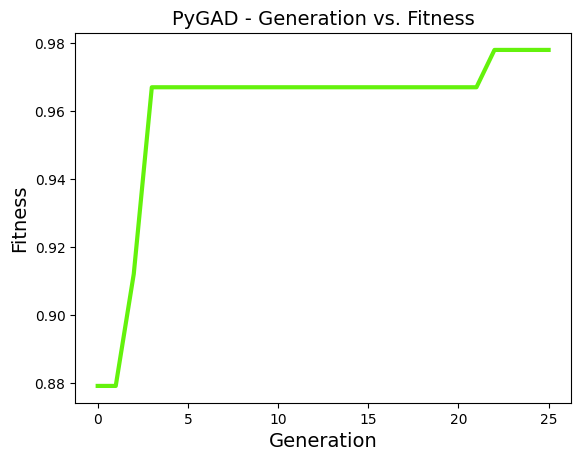


--- Evolucion Finalizada ---
Mejor cromosoma encontrado: [ 1.64498453 -1.53033102  2.15906587  2.18130967 -2.56829237  0.48523043
  1.11329746  0.95080065  3.35932978  1.19047512]
Precision (Fitness) obtenida: 0.9780
Indice de la solucion: 0


In [ ]:
import warnings
from sklearn.exceptions import ConvergenceWarning

def main():
    # Hacemos que 'ga' sea global para poder acceder a los resultados desde otras celdas
    global ga

    # Silenciar las advertencias de convergencia de scikit-learn durante la optimizacion
    warnings.filterwarnings("ignore", category=ConvergenceWarning)

    # 1. Configuracion del optimizador genetico
    ga = pygad.GA(num_generations=25,
                  num_parents_mating=2,
                  fitness_func=fitness_func,
                  sol_per_pop=10,
                  num_genes=5 + max_hidden)

    # 2. Ejecutar la evolucion
    ga.run()

    # 3. Graficar la evolucion de la aptitud a lo largo de las generaciones
    ga.plot_fitness()

    # 4. Extraer y presentar el mejor resultado obtenido
    solution, solution_fitness, solution_idx = ga.best_solution()
    print(f"\n--- Evolucion Finalizada ---")
    print(f"Mejor cromosoma encontrado: {solution}")
    print(f"Precision (Fitness) obtenida: {solution_fitness:.4f}")
    print(f"Indice de la solucion: {solution_idx}")

if __name__ == '__main__':
    main()